## Setup

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("if_visualiser.ipynb"), '..')))

from inflection_finder.normaliser import *
from inflection_finder import visualiser

In [4]:
plates = ["plate-1", "plate-2", "plate-3", "plate-4", "plate-5","plate-6"]
uniform_path = "uniform-plate"

## Normalising Inflection Intensity
For each inflection intensity file, normalise against uniform plate intensity.

Since uniform inflection times is roughly uniform, no need to normalise per experiment.

In [5]:
normalise_plates(uniform_path, plates, "intensity", cap_size=1)

Saved output/intensity/plate-1-corrected.csv
Saved output/intensity/plate-2-corrected.csv
Saved output/intensity/plate-3-corrected.csv
Saved output/intensity/plate-4-corrected.csv
Saved output/intensity/plate-5-corrected.csv
Saved output/intensity/plate-6-corrected.csv


## Combining Intensity Data

In [ ]:
# Intensity data
combined_intensity = [os.path.join("..", "experiments", plate, "output", "intensity_points.csv") for plate in plates]
combined_intensity_output_path = os.path.join("output", "intensity", "combined_intensity.csv")

combine_well_matrix_csvs(combined_intensity, combined_intensity_output_path)

Saved combined CSV to output/intensity/combined_intensity.csv


'output/intensity/combined_intensity.csv'

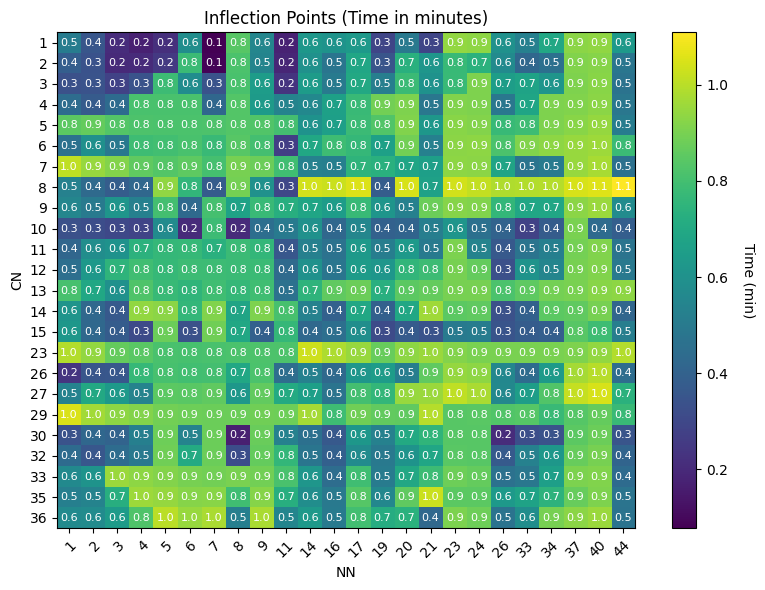

In [ ]:
visualiser.plot_inflection_csv(combined_intensity_output_path, show_annotations=True)

In [ ]:
# Normalised intensity data
normalised_combined_intensity = [os.path.join("output", "intensity", f"{plate}-corrected.csv") for plate in plates]


combine_well_matrix_csvs(normalised_combined_intensity, os.path.join("output", "intensity", "combined_corrected_intensity.csv"))

Saved combined CSV to output/intensity/combined_corrected_intensity.csv


'output/intensity/combined_corrected_intensity.csv'

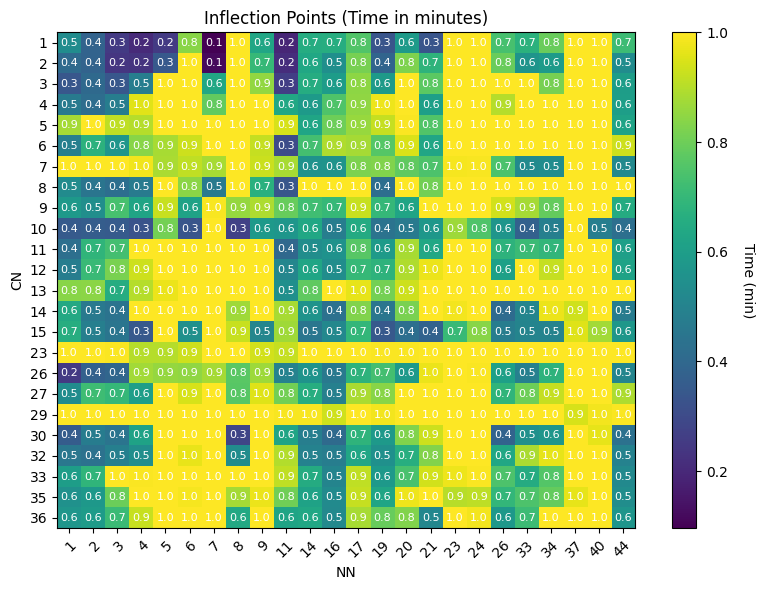

In [20]:
visualiser.plot_inflection_csv("output/intensity/combined_corrected_intensity.csv", show_annotations=True)

## Combining Inflection Data

In [23]:
# Inflection data
csv_list3 = [os.path.join("..", "experiments", plate, "output", "inflection_points.csv") for plate in plates]
combine_well_matrix_csvs(csv_list3, os.path.join("output", "inflection", "combined_inflection.csv"))

Saved combined CSV to output/inflection/combined_inflection.csv


'output/inflection/combined_inflection.csv'

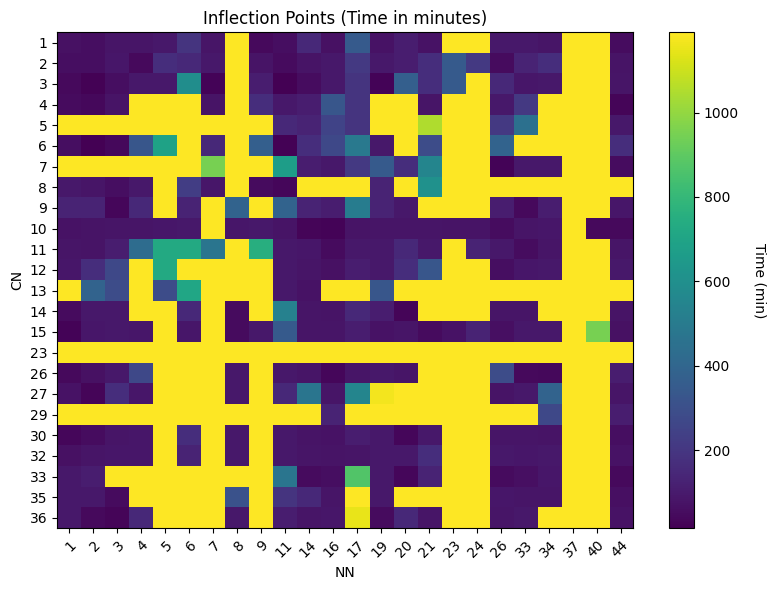

In [24]:
visualiser.plot_inflection_csv("output/inflection/combined_inflection.csv", show_annotations=False)

## Finding Inflection Rates
Assuming the signal changes approximately linearly from time 0 to the inflection point, each well starts at normalized intensity 1 and darkens until its measured inflection intensity. Therefore, the inflection rate can be estimated by combining the inflection time and intensity-at-inflection as the slope from the starting point to the inflection point.

In [11]:
calculate_inflection_rates(
    intensity_csv="output/intensity/combined_intensity.csv",
    inflection_csv="output/inflection/combined_inflection.csv",
    max_inflection=1190,
    output_csv="output/rate.csv"
);

Saved inflection rates to output/rate.csv


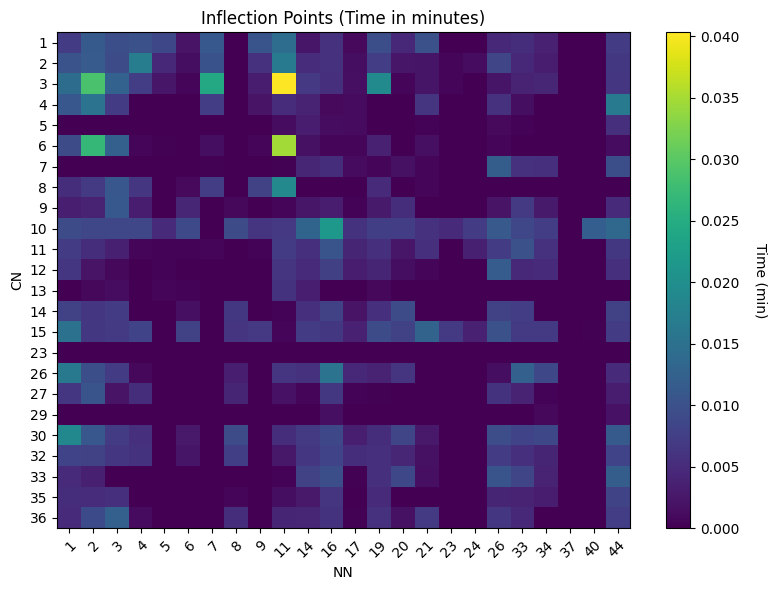

In [12]:
visualiser.plot_inflection_csv("output/rate.csv", show_annotations=False)

In [9]:
# Corrected inflection rates
calculate_inflection_rates(
    intensity_csv="output/intensity/combined_corrected_intensity.csv",
    inflection_csv="output/inflection/combined_inflection.csv",
    max_inflection=1190,
    output_csv="output/corrected_rate.csv"
);

Saved inflection rates to output/corrected_rate.csv


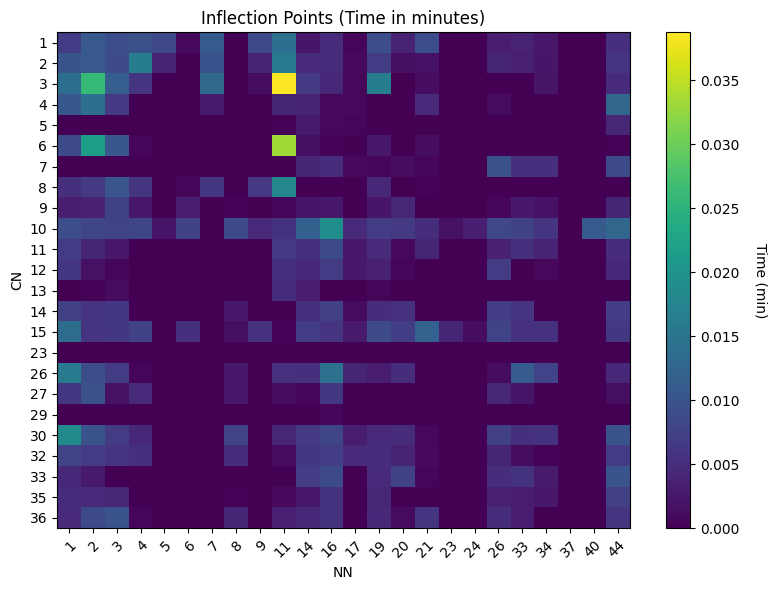

In [10]:
visualiser.plot_inflection_csv("output/corrected_rate.csv", show_annotations=False)